### Load Data and Preprocess
This cell loads the CTA ridership data from Kagglehub, renames columns, sets the 'date' column as the index, drops the 'total' column (as 'bus' and 'rail' sum to it), and removes any duplicate entries.

In [3]:
import pandas as pd
import kagglehub
from pathlib import Path

path = kagglehub.dataset_download("chicago/chicago-transit-authority-cta-data")

path = Path(path)

print("Path to dataset files:", path)

df = pd.read_csv(path / "cta-ridership-daily-boarding-totals.csv",parse_dates=["service_date"])

df.columns= ["date", "day_type", "bus", "rail", "total"]
df = df.sort_values("date").set_index("date")
df = df.drop("total",axis=1)
df = df.drop_duplicates()
df.head()

100%|██████████| 12.1M/12.1M [00:00<00:00, 46.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/chicago/chicago-transit-authority-cta-data/versions/9


,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


### Plot Ridership for a Specific Period
This cell visualizes the 'bus' and 'rail' ridership data for a specific period (March to May 2019) to observe trends and patterns. It uses `matplotlib` for plotting and sets the title, labels, and grid for better readability.

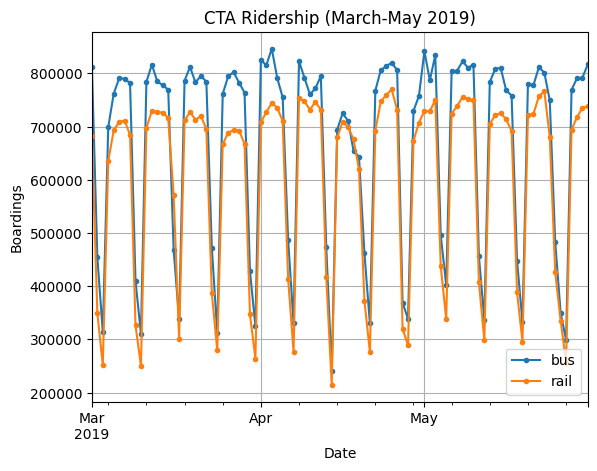

In [4]:
import matplotlib.pyplot as plt
df["2019-03":"2019-05"].plot(grid=True,marker='.', title="CTA Ridership (March-May 2019)", ylabel="Boardings", xlabel="Date")
plt.show()

### 7-Day Differencing
This cell performs a 7-day differencing operation on the 'bus' and 'rail' ridership data. It then plots the original data along with the 7-day lagged data and the differenced series. This helps in analyzing weekly seasonality and making the time series more stationary.

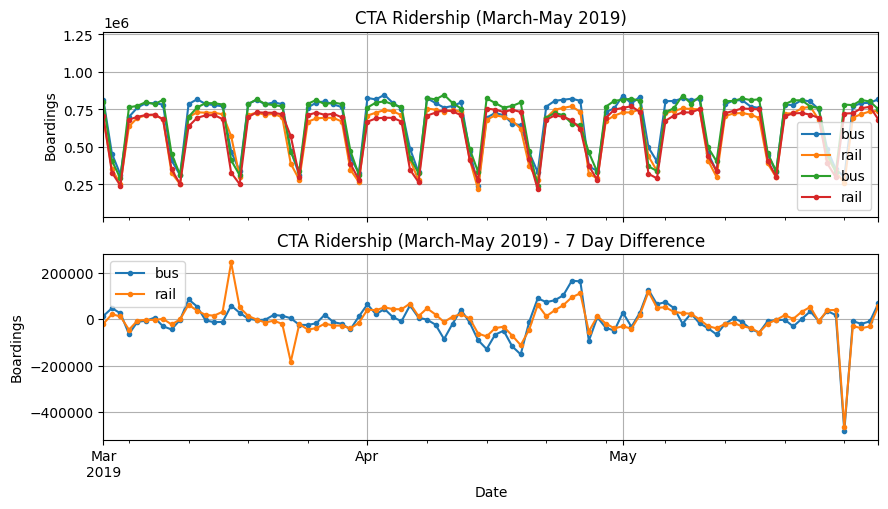

In [5]:
#Differencing
diff_7 = df[["bus","rail"]].diff(7)["2019-03":"2019-05"]
fig,axs = plt.subplots(2,1,sharex=True,figsize=(10,6))
df.plot(ax=axs[0],grid=True,marker='.', title="CTA Ridership (March-May 2019)", ylabel="Boardings", xlabel="Date")
df.shift(7).plot(ax=axs[0],grid=True,marker='.', title="CTA Ridership (March-May 2019)", ylabel="Boardings", xlabel="Date")
diff_7.plot(ax=axs[1],grid=True,marker='.', title="CTA Ridership (March-May 2019) - 7 Day Difference", ylabel="Boardings", xlabel="Date")
plt.show()

### Display Day Types
This cell retrieves and displays the 'day_type' for a specific date range (May 25th to May 27th, 2019). This helps in understanding the type of day (e.g., 'A' for Average, 'U' for Weekend/Holiday, 'W' for Weekday) for specific dates.

In [6]:
list(df.loc["2019-05-25":"2019-05-27"]["day_type"])

['A', 'U', 'U']

### Calculate Mean Absolute 7-Day Difference
This cell calculates the mean of the absolute values of the 7-day differenced 'bus' and 'rail' ridership data. This metric provides an insight into the average magnitude of weekly changes in ridership.

In [7]:
diff_7.abs().mean()

,0
bus,43915.608696
rail,42143.271739


### Calculate Mean Absolute Percentage Error (MAPE) for 7-Day Difference
This cell calculates the Mean Absolute Percentage Error (MAPE) of the 7-day differenced data relative to the original ridership values for the specified period. It provides a normalized measure of the average percentage difference between consecutive weeks.

In [8]:
target = df[["bus","rail"]]["2019-03":"2019-05"]
(diff_7/target).abs().mean()

,0
bus,0.082938
rail,0.089948


### Monthly Mean and 12-Month Rolling Average
This cell calculates the monthly mean ridership for 'bus' and 'rail' using month-end resampling ('ME'). It then computes a 12-month rolling average for the period 2001-2019. Finally, it plots both the monthly mean and the rolling average to visualize long-term trends and seasonality.

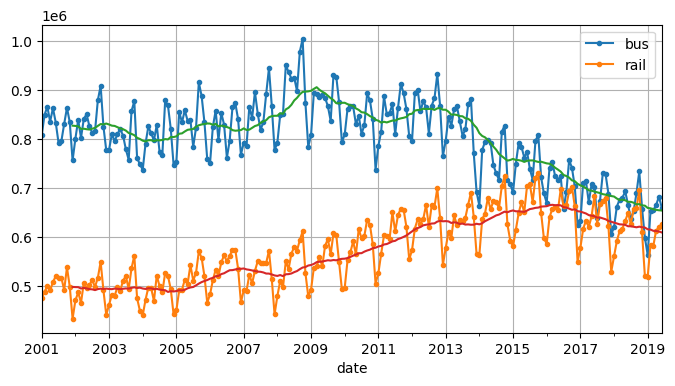

In [11]:
import matplotlib.pyplot as plt

period = slice("2001","2019")
df_monthly = df[["bus","rail"]].resample("ME").mean() # Monthly mean
rolling_average_12_months = df_monthly[period].rolling(window=12).mean()

fig,ax = plt.subplots(figsize =(8,4))
df_monthly.plot(ax=ax,marker='.')
rolling_average_12_months.plot(ax=ax,grid=True,legend=False)
plt.show()

### Plot 12-Month Difference of Monthly Mean Ridership
This cell computes the 12-month difference of the monthly mean ridership and plots it for the period 2001-2019. This differencing helps in removing yearly seasonality and making the series more stationary for further analysis.

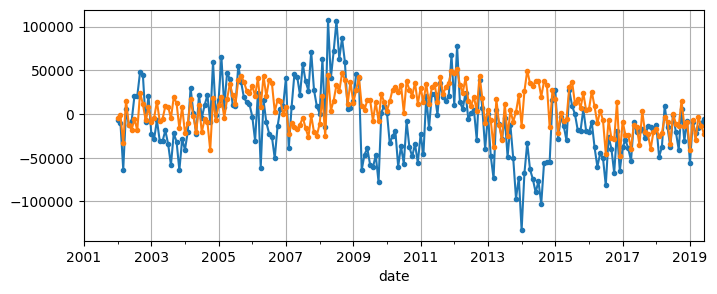

In [13]:
df_monthly.diff(12)[period].plot(grid=True,marker='.', legend=False,figsize=(8,3))
plt.show()